# Exercises 8

Variational Principle and Simulated Annealing.

## Exercise 8.1

We are asked to make a variational monte carlo code for a single quantum particle in 1D, to calculate the expectation value of the hamiltonian:

$$
\langle {\hat H} \rangle = 
\frac{\int dx \Psi^*(x) {\hat H} \Psi(x)}
{\int dx |\Psi(x)|^2} = 
\int dx \frac{|\Psi(x)|^2}{\int dx |\Psi(x)|^2} \frac{{\hat H} \Psi(x)}{\Psi(x)}
$$

Where the hamiltonian $\hat H = \hat T + \hat V(x)$ is the sum of the kinetic $\hat T$ and potential term $\hat V(x) = x^4 - \frac{5}{2}x^2$.

For this potential we don't have an analytichal solution, so we have to make a guess of the wavefunction $\Psi(x)$. Since the potential resembles two symmetrical harmonic minima we can guess that the ground state should be similar to the sum of the two ground state wave functions of the harmonic potential, so the sum of two gaussian functions:

$$
\Psi_\text{trial}^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
Where $\mu$ and $\sigma$ are two parameters to be optimized.

### Markov Chain

To calculate the expected value of H we use a markov chain:
- propose a new position $x_{n+1} = x_n + \gamma_x \mathcal U (-1, 1)$, where $U$ is a uniform distribution, and $\gamma_x$ is a parameter.
- accept the proposed move with probability $p = \min\left(1, \frac{|\Psi(x_{n+1})|^2}{|\Psi(x_n)|^2} \right)$.

This generates a chain that samples points from $|\Psi|^2$.
Then we just need to calculate $\hat H (x_n)$ using data blocking to get $\langle\hat H\rangle$.

#### Other details

From the potential I choose a fixed value of $\mu = 0.8$ and $\sigma = 0.5$.

To keep the markov chain moving I choose to keep the acceptance of $x$ near $0.5$, to achieve this I choose $\gamma_x = 2.2$ which gives an acceptance of $\sim 57\%$.

Since the markov chain need a bit of time to adjust itself i added 2 blocks of burn in before taking any measurement of $\hat H$.

I also made two classes:
- `WaveFunction`: Stores the trial wavefunction (sum of two Gaussians centered at $\pm \mu$ both with width $\sigma$). Computes $\Psi(x)$, $|\Psi|^2$, kinetic and potential energy, and the total hamiltonian $\hat H$.
- `DataBlocking`: Estimates average and error using datablocking.

## Exercise 8.2

We then need to find the best parameters $(\mu, \sigma)$ that minimize $\langle\hat H\rangle$.

To find them I used the Simulated Annealing (SA) algorithm:
- Propose new $(\mu, \sigma)$ using a uniform transition.
- Evaluate $\langle\hat H\rangle$ for the new parameters.
- Accept the new parameters with probability $p = \min \left(1, \exp{-\frac{E_C-E_P}{T}}\right)$, where $E_C$ is the current evaluation of the hamiltonian and $E_P$ is the previous accepted, $T$ is the temperature.
- Cool down the temperature.

After the SA steps I made another evaluation of $\langle\hat H\rangle$ with an increased number of blocks and throws (both 10 times more).

### Details

I choose to use $3000$ SA steps, for each one, the estimation of $\langle\hat H\rangle$ uses $1000$ blocks of $500$ throws each. 

The temperature drops as:
$$
T = \frac{C_e^{m}}{1 + C_i \cdot n}
$$
Where $n$ is the number of SA steps, $m = \text{floor}(n / 100)$ and $C_e = 0.98$, $C_i = 0.1$ are constants. This cooling schedule combines two regimes: the $1/n$ term dominates initially, providing rapid early cooling, while the exponential term $C_e^{m}$ becomes significant at large $n$, ensuring faster temperature decay in later stages of the SA. Overall this cooling schedule drops the temperature 

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

We are asked to show the value of $\langle \hat H \rangle$ as a function of the SA steps.

To better show the results I will also need to calculate the solution using matrix inversion algorithms, to compare the simulated solution to the real solution.

In [2]:
# calculate the ground state energy and wavefunction of the system using matrix inversion
def Vpot(x):
    return (x**2 - 2.5) * x**2


hbar = 1
m = 1
a = 6
N = 1000  # number of samples

# Step sizes
x = np.linspace(-a / 2, a / 2, N)
dx = a / N
V = Vpot(x)

CDiff = (
    np.diag(np.ones(N - 1), -1)
    - 2 * np.diag(np.ones(N), 0)
    + np.diag(np.ones(N - 1), 1)
)

# Hamiltonian matrix
H = (-(hbar**2) * CDiff) / (2 * m * dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E, psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi / np.sqrt(dx)

g_s_energy = E[0]  # Ground state energy of the system

print(f"Ground state energy: {g_s_energy:.5f}")

Ground state energy: -0.45982


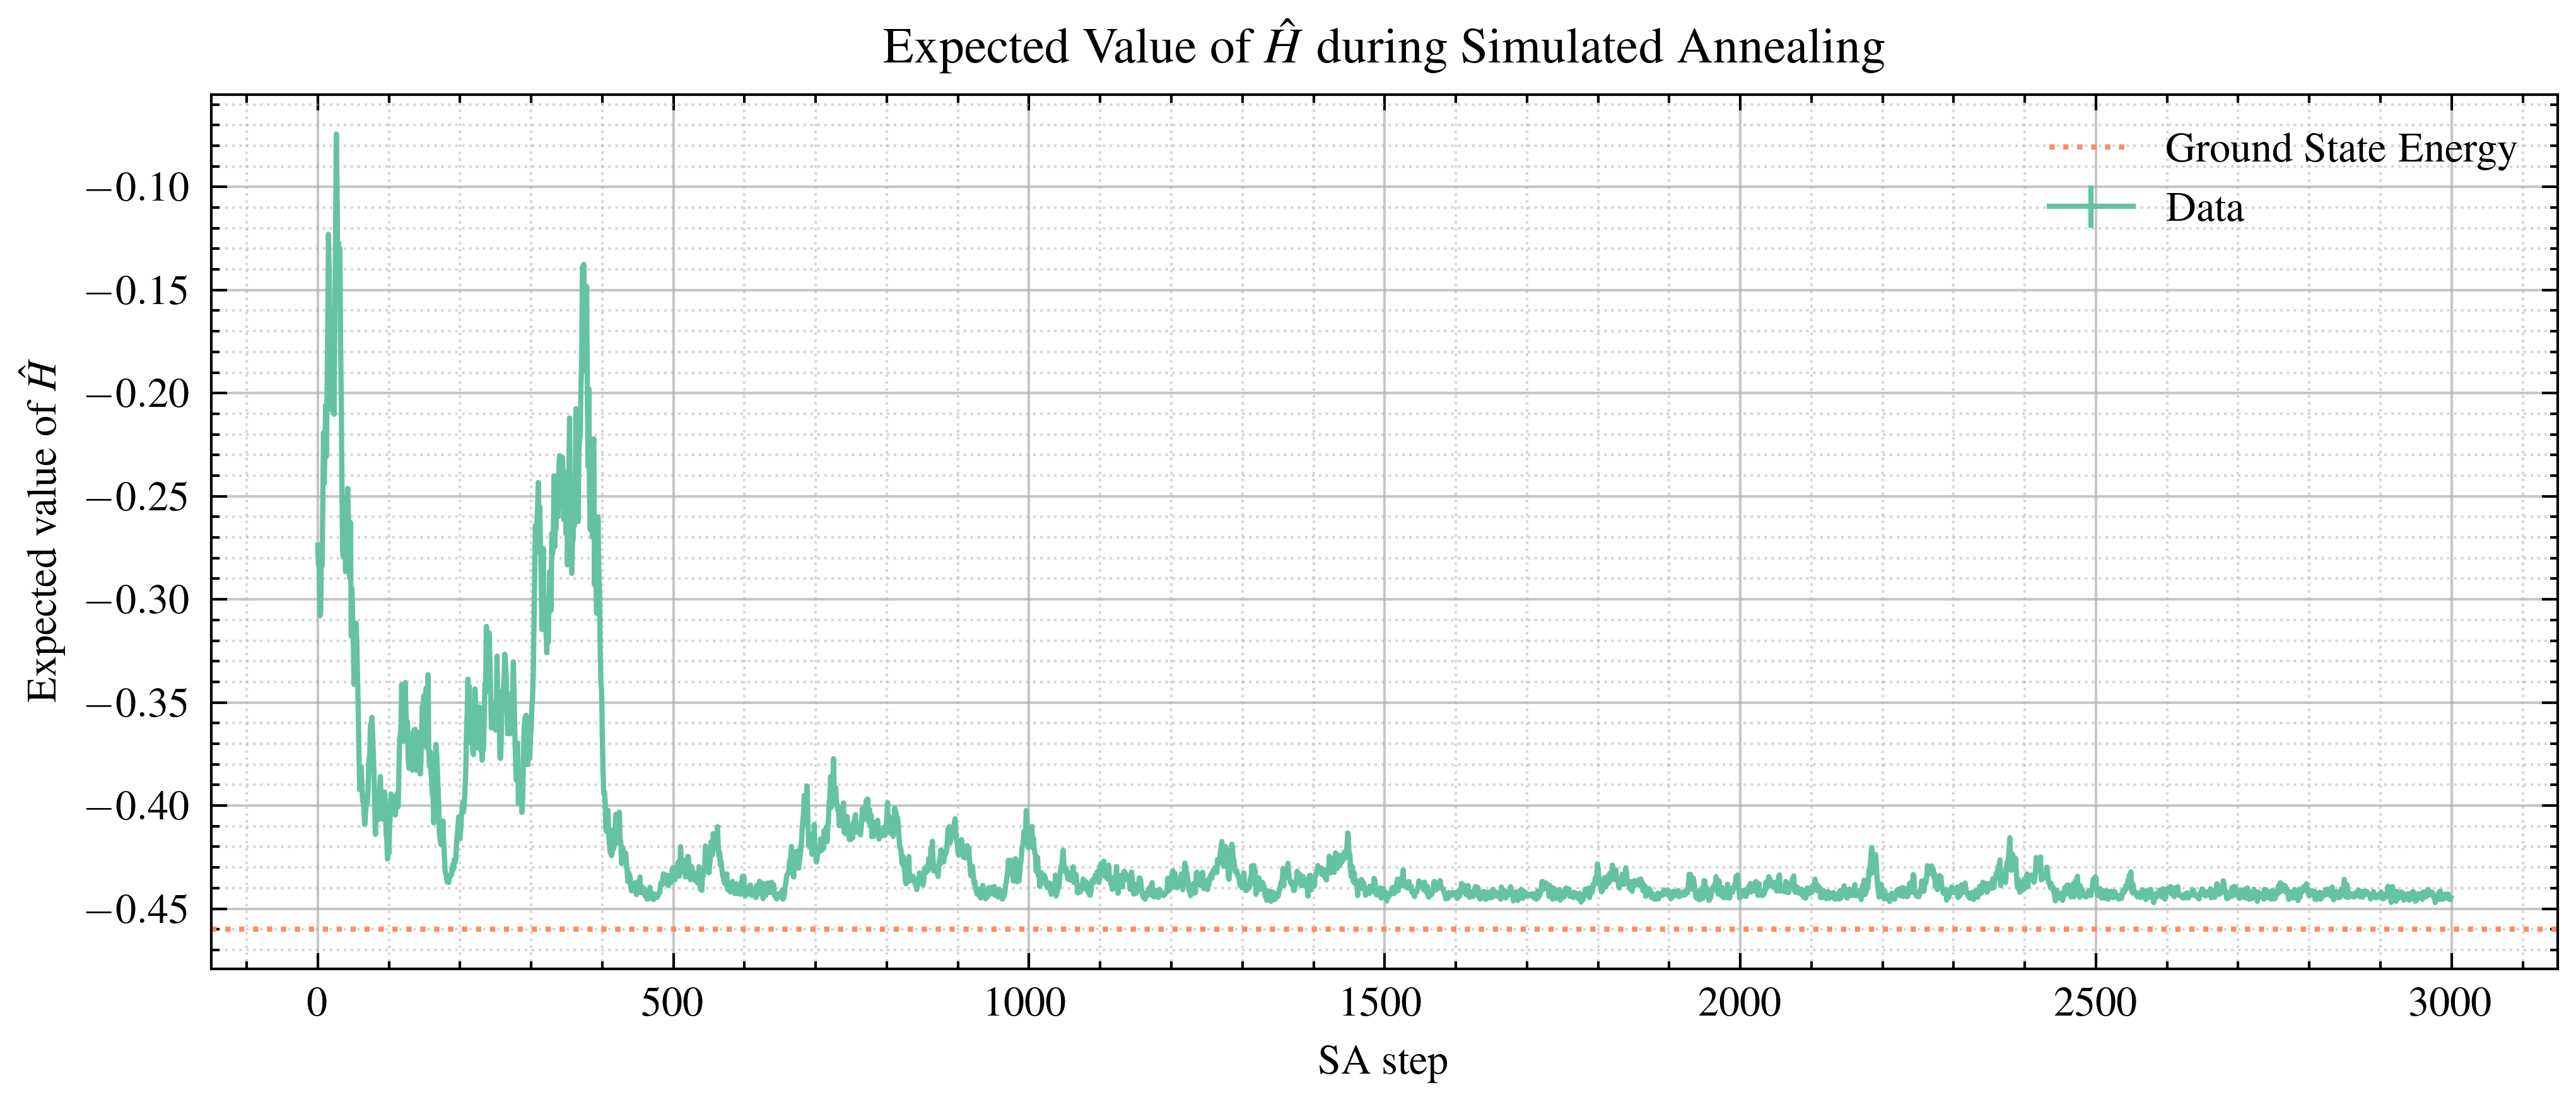

In [3]:
H_sa = np.loadtxt("../Exercises/Exercises_08/Exer_08_02/data/expected_H_annealing.dat")
# ^^^ columns are: SA step, expected value of H, error on expected value of H

fig = plt.figure(figsize=(8, 3))

plt.axhline(g_s_energy, linestyle=":", label="Ground State Energy", c="C1")
plt.errorbar(H_sa[:, 0], H_sa[:, 1], yerr=H_sa[:, 2], label="Data", errorevery=100)

plt.title(r"Expected Value of $\hat H$ during Simulated Annealing")
plt.xlabel("SA step")
plt.ylabel(r"Expected value of $\hat H$")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle=":", alpha=0.5)

plt.show()

We can see that the expected value of the hamiltonian approaches with some noise to the ground state but never reaches the real value.

That's an expected result since we used a trial wavefunction $\Psi_T^{\mu, \sigma}(x)$ that might not include the ground state. We will see this in more detail later on.

Then we are asked to show how the parameters change during the SA. 

Below on the left is a plot with the value of the parameters as a function of the SA steps, while on the right there is the trajectory in the parameter space.

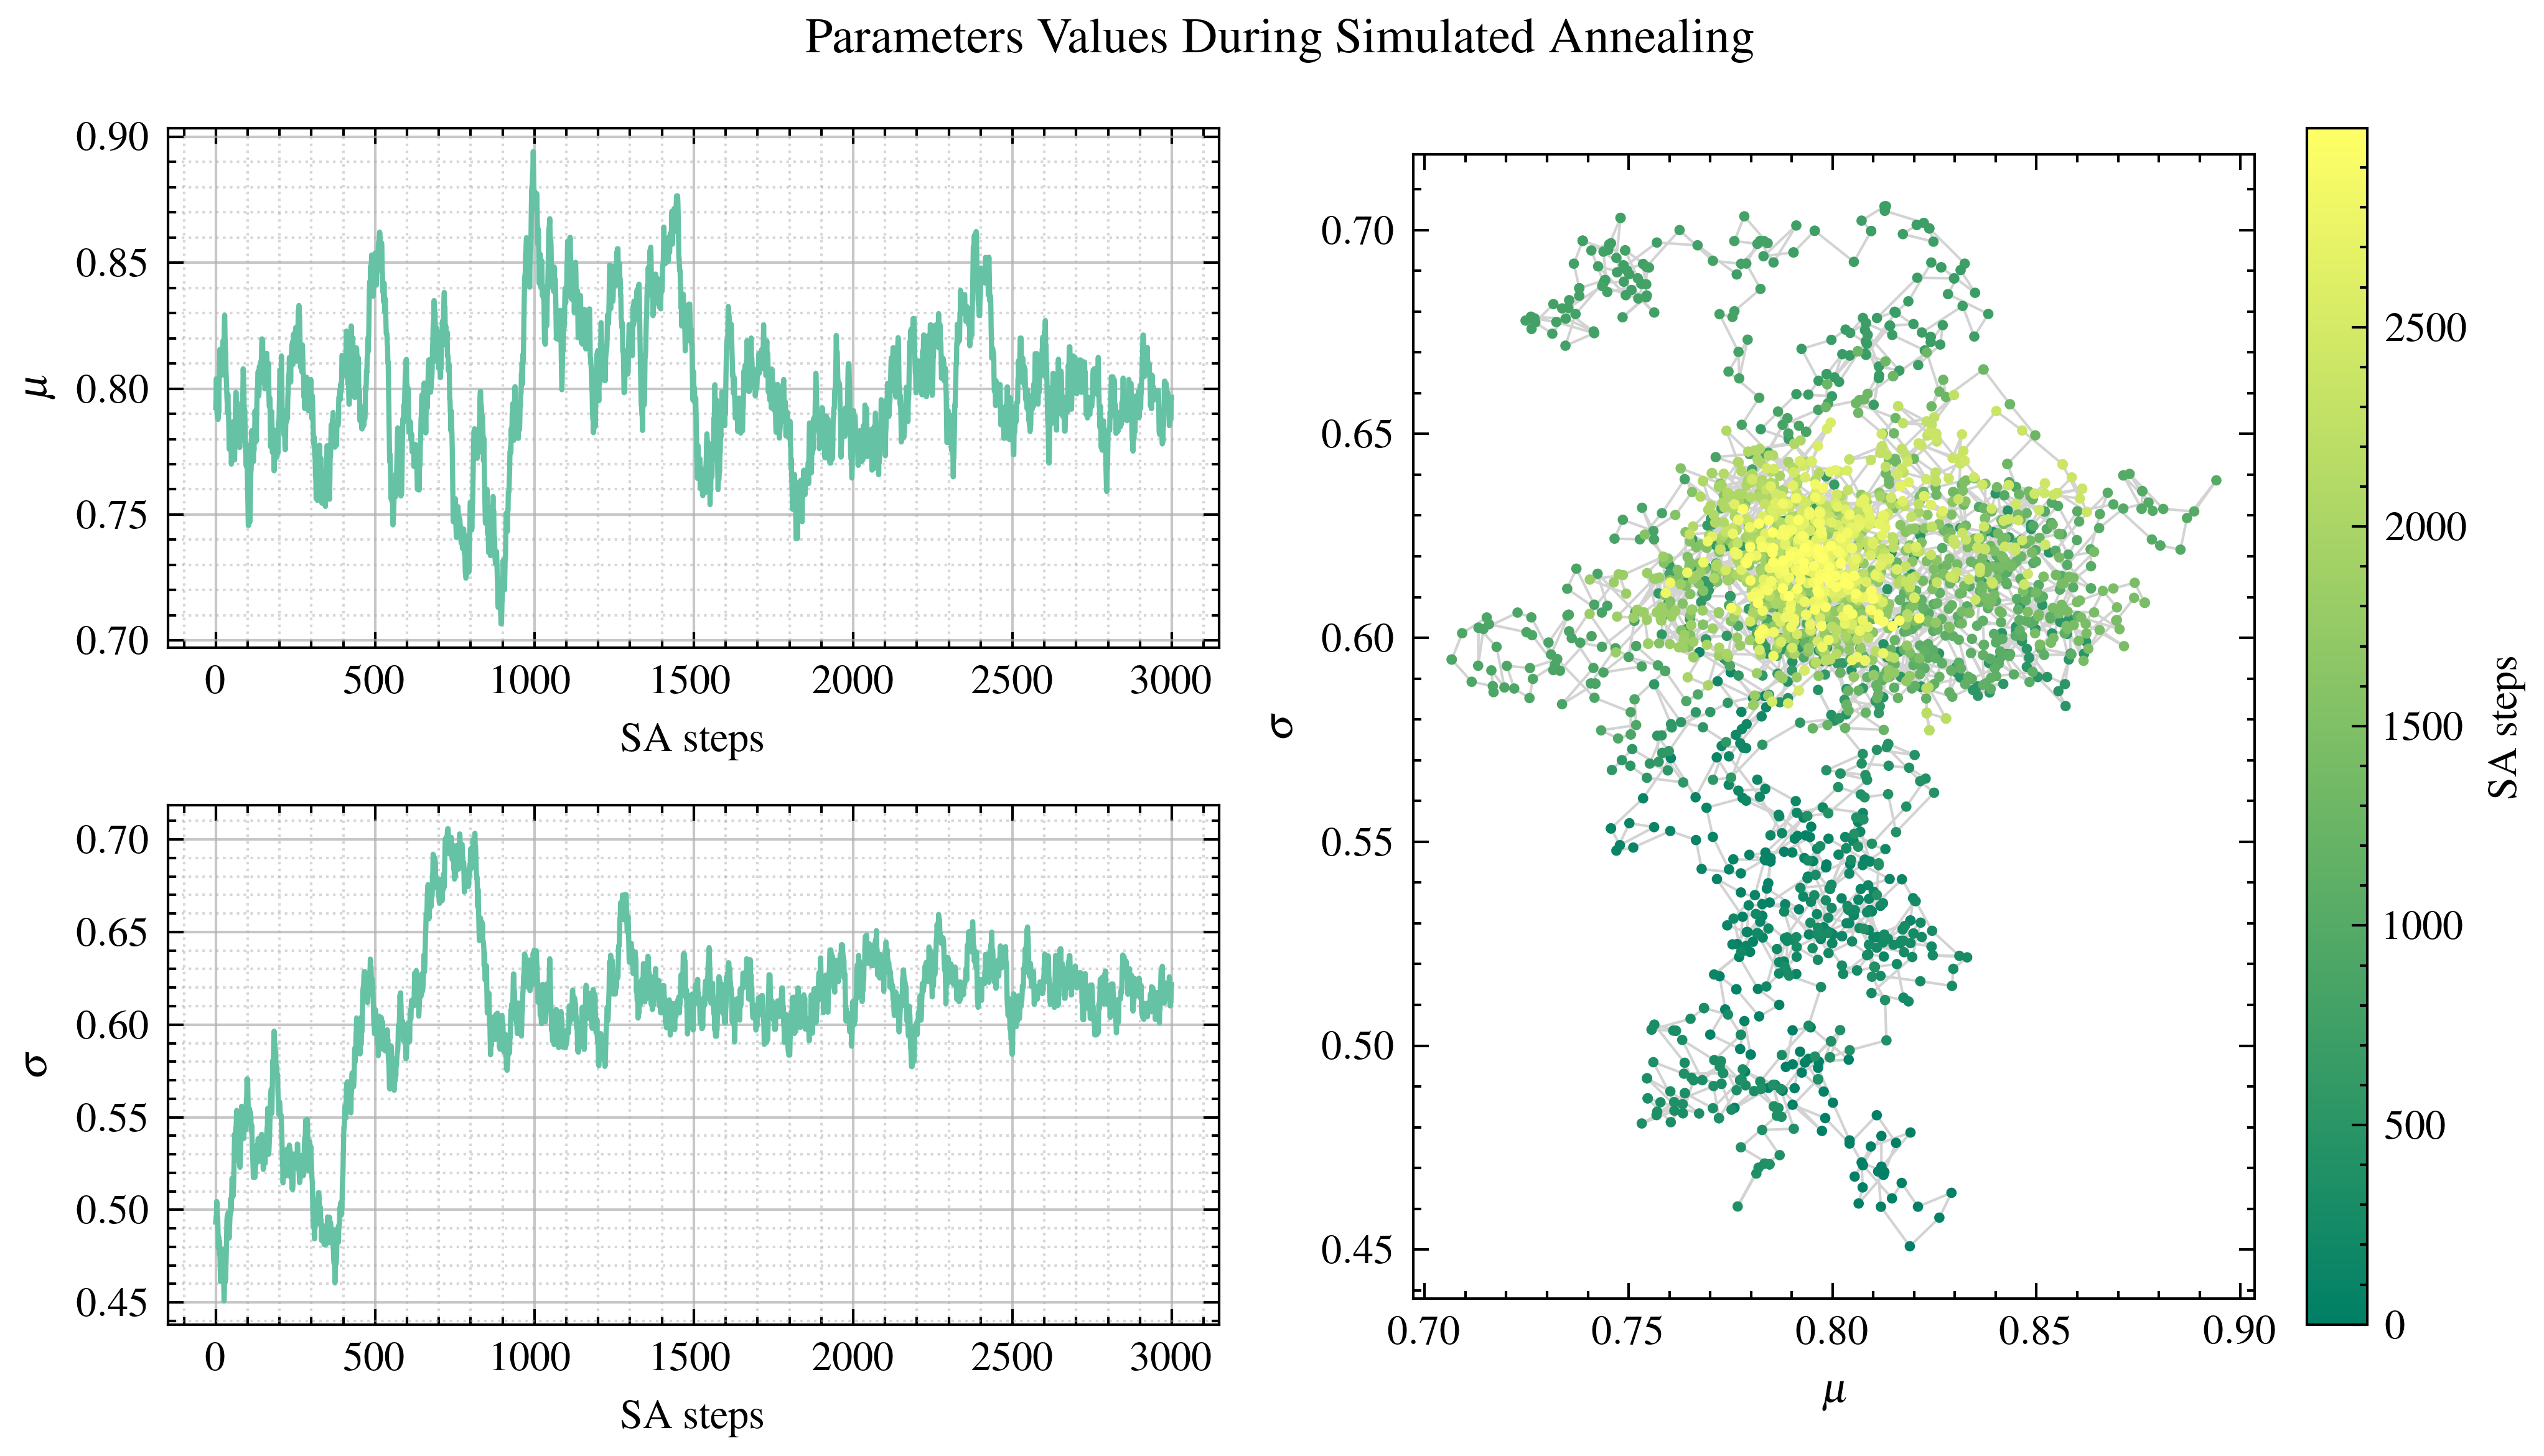

In [4]:
params = np.loadtxt("../Exercises/Exercises_08/Exer_08_02/data/paramters.dat")
# ^^^ columns are: SA step, mu, sigma

fig = plt.figure(figsize=(7, 4))

# setup a 2x2 grid of subplots, with the last one spanning both rows
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[:, 1])

# plot mu
ax1.plot(params[:, 0], params[:, 1])

ax1.set_ylabel(r"$\mu$")
ax1.set_xlabel(r"SA steps")

ax1.grid(True, which="major", alpha=0.7)
ax1.grid(True, which="minor", linestyle=":", alpha=0.5)

# plot sigma
ax2.plot(params[:, 0], params[:, 2])

ax2.set_ylabel(r"$\sigma$")
ax2.set_xlabel(r"SA steps")

ax2.grid(True, which="major", alpha=0.7)
ax2.grid(True, which="minor", linestyle=":", alpha=0.5)

# plot the trajectory of (mu, sigma)
ax3.plot(params[:, 1], params[:, 2], color="lightgray", lw=0.5, zorder=-1)
scatter = ax3.scatter(params[:, 1], params[:, 2], c=params[:, 0], cmap="summer", s=1)
plt.colorbar(scatter, ax=ax3, label="SA steps")

ax3.set_xlabel(r"$\mu$")
ax3.set_ylabel(r"$\sigma$")

ax3.set_aspect("equal")


plt.suptitle("Parameters Values During Simulated Annealing")

plt.tight_layout()
plt.show()

We can see that the parameters wiggle around $(\mu = 0.8, \sigma = 0.6)$. 

As we decrease the temperature we see the noise decreasing a bit.

Using the best parameters I then use the final parameters to make a longer final calculation of $\langle \hat H \rangle$.

final parameters: mu = 0.7966, sigma = 0.6217
final expected value of H: -0.4442 ± 0.0001


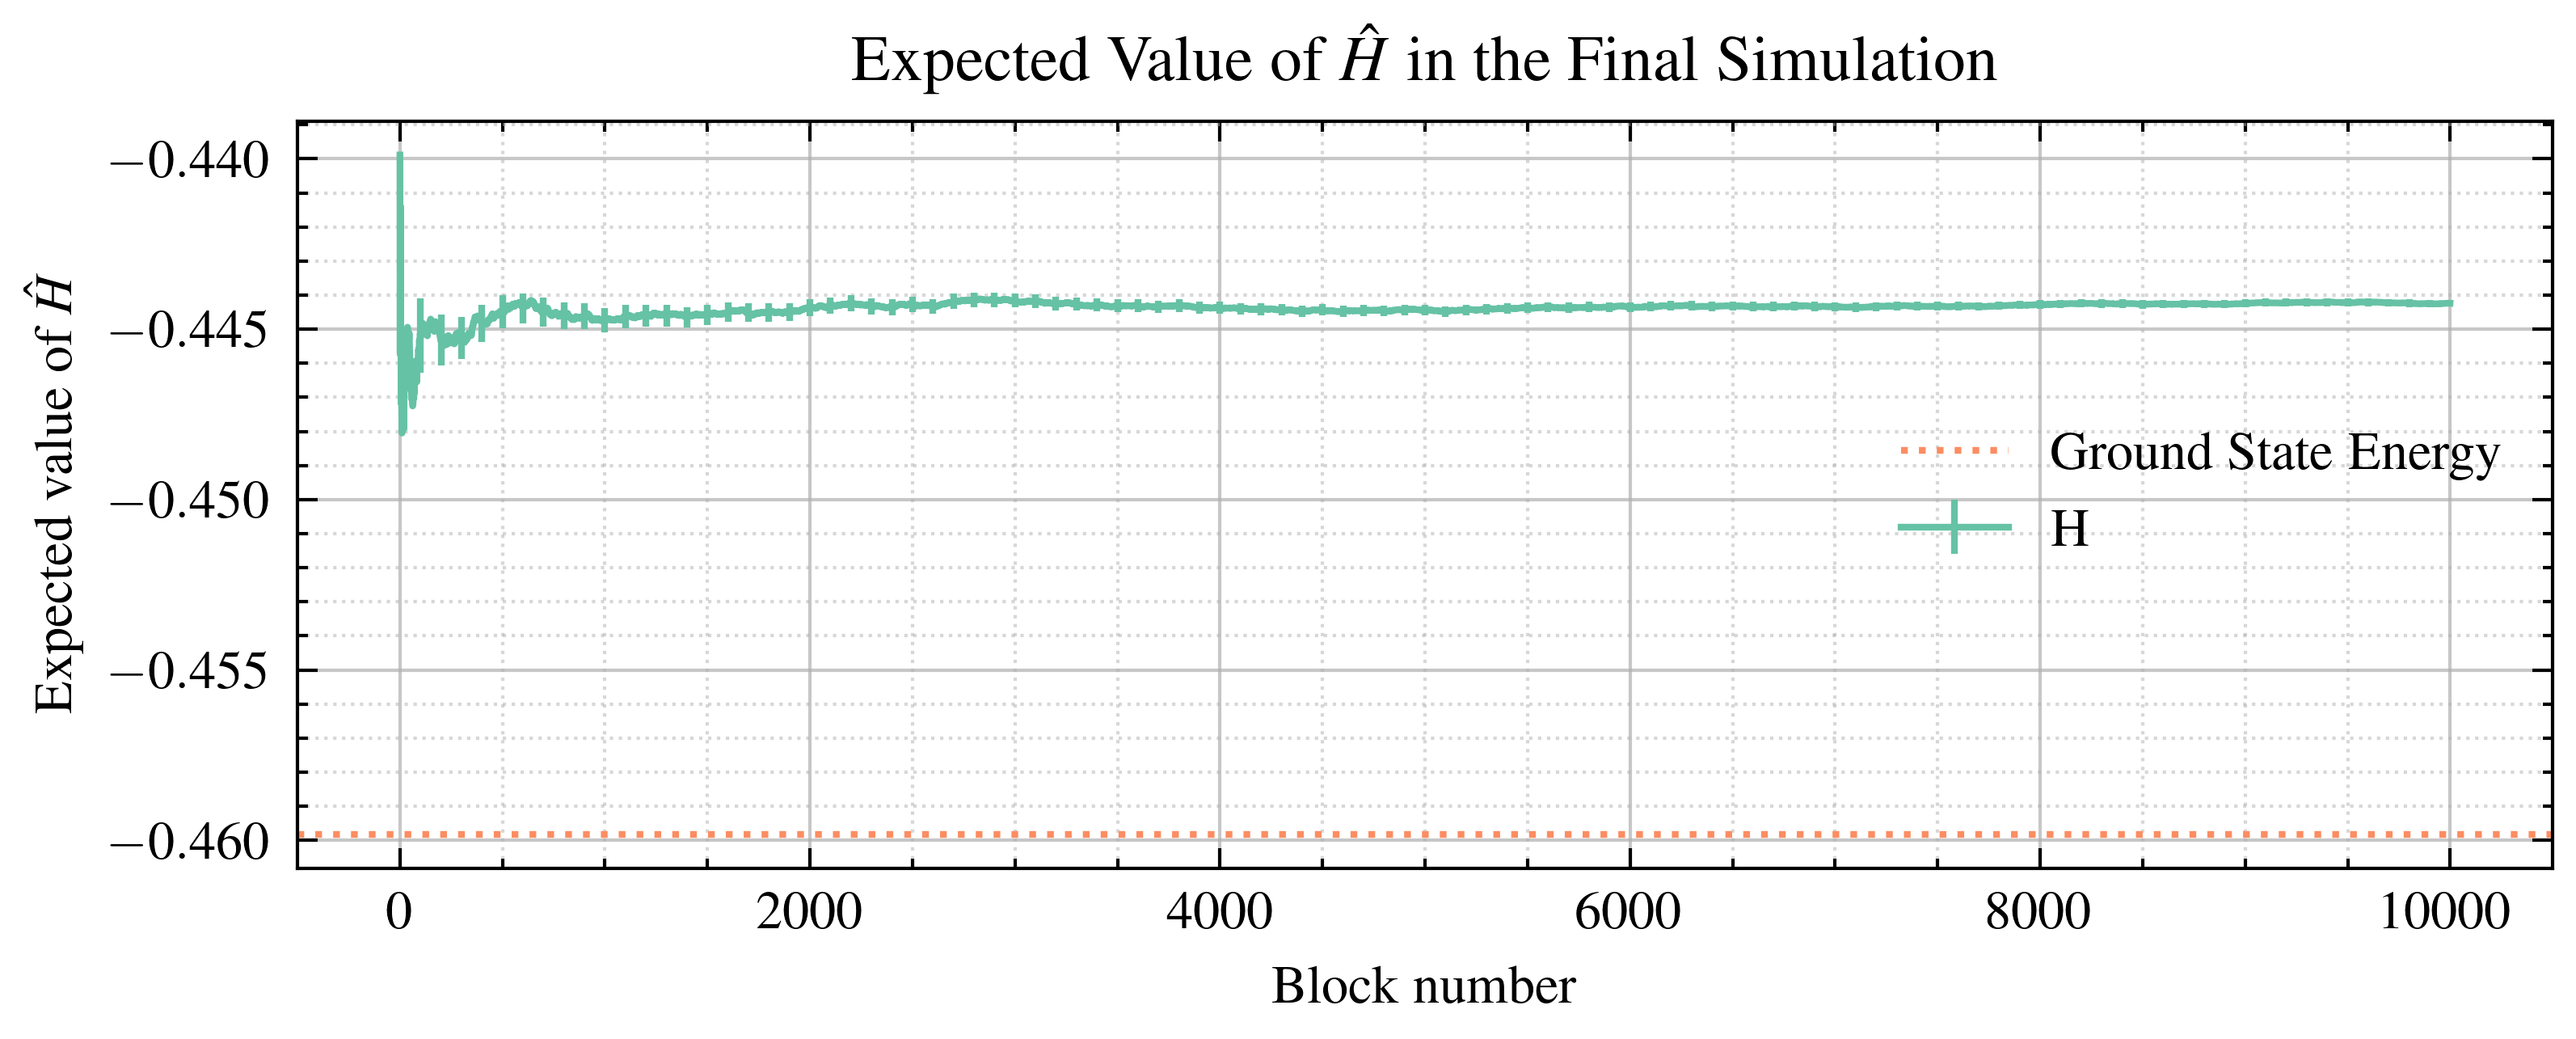

In [5]:
energy = np.loadtxt("../Exercises/Exercises_08/Exer_08_02/data/H_expected.dat")
# ^^^ columns are: block number, expected value of H, error on expected value of H

# print the final parameters and the final expected value of H
print(f"final parameters: mu = {params[-1, 1]:.4f}, sigma = {params[-1, 2]:.4f}")
print(f"final expected value of H: {energy[-1, 1]:.4f} ± {energy[-1, 2]:.4f}")


fig = plt.figure(figsize=(6, 2))

plt.errorbar(energy[:, 0], energy[:, 1], yerr=energy[:, 2], label="H", errorevery=100)
plt.axhline(g_s_energy, linestyle=":", label="Ground State Energy", c="C1")

plt.title(r"Expected Value of $\hat H$ in the Final Simulation")
plt.xlabel("Block number")
plt.ylabel(r"Expected value of $\hat H$")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle=":", alpha=0.5)

plt.show()

From this figure it is even more evident that the expected value of the hamiltonian using the trial wavefunction is not compatible with the ground state obtained using the matrix inversion.

We then show an histogram (100 bins) with the sampled wavefunction and come pare with the trial wavefunction obtained using the final parameters and with the ground state obtained from matrix inversion.

In [6]:
# compute the expected value of H with the optimized parameters
def expected_H(x, mu, sigma):
    return (
        np.exp(-((x - mu) ** 2) / (2 * sigma**2))
        + np.exp(-((x + mu) ** 2) / (2 * sigma**2))
    ) / (2 * np.pi**0.5 * sigma * (1 + np.exp(-(mu**2) / sigma**2))) ** 0.5


psi_best = expected_H(x, params[-1, 1], params[-1, 2])

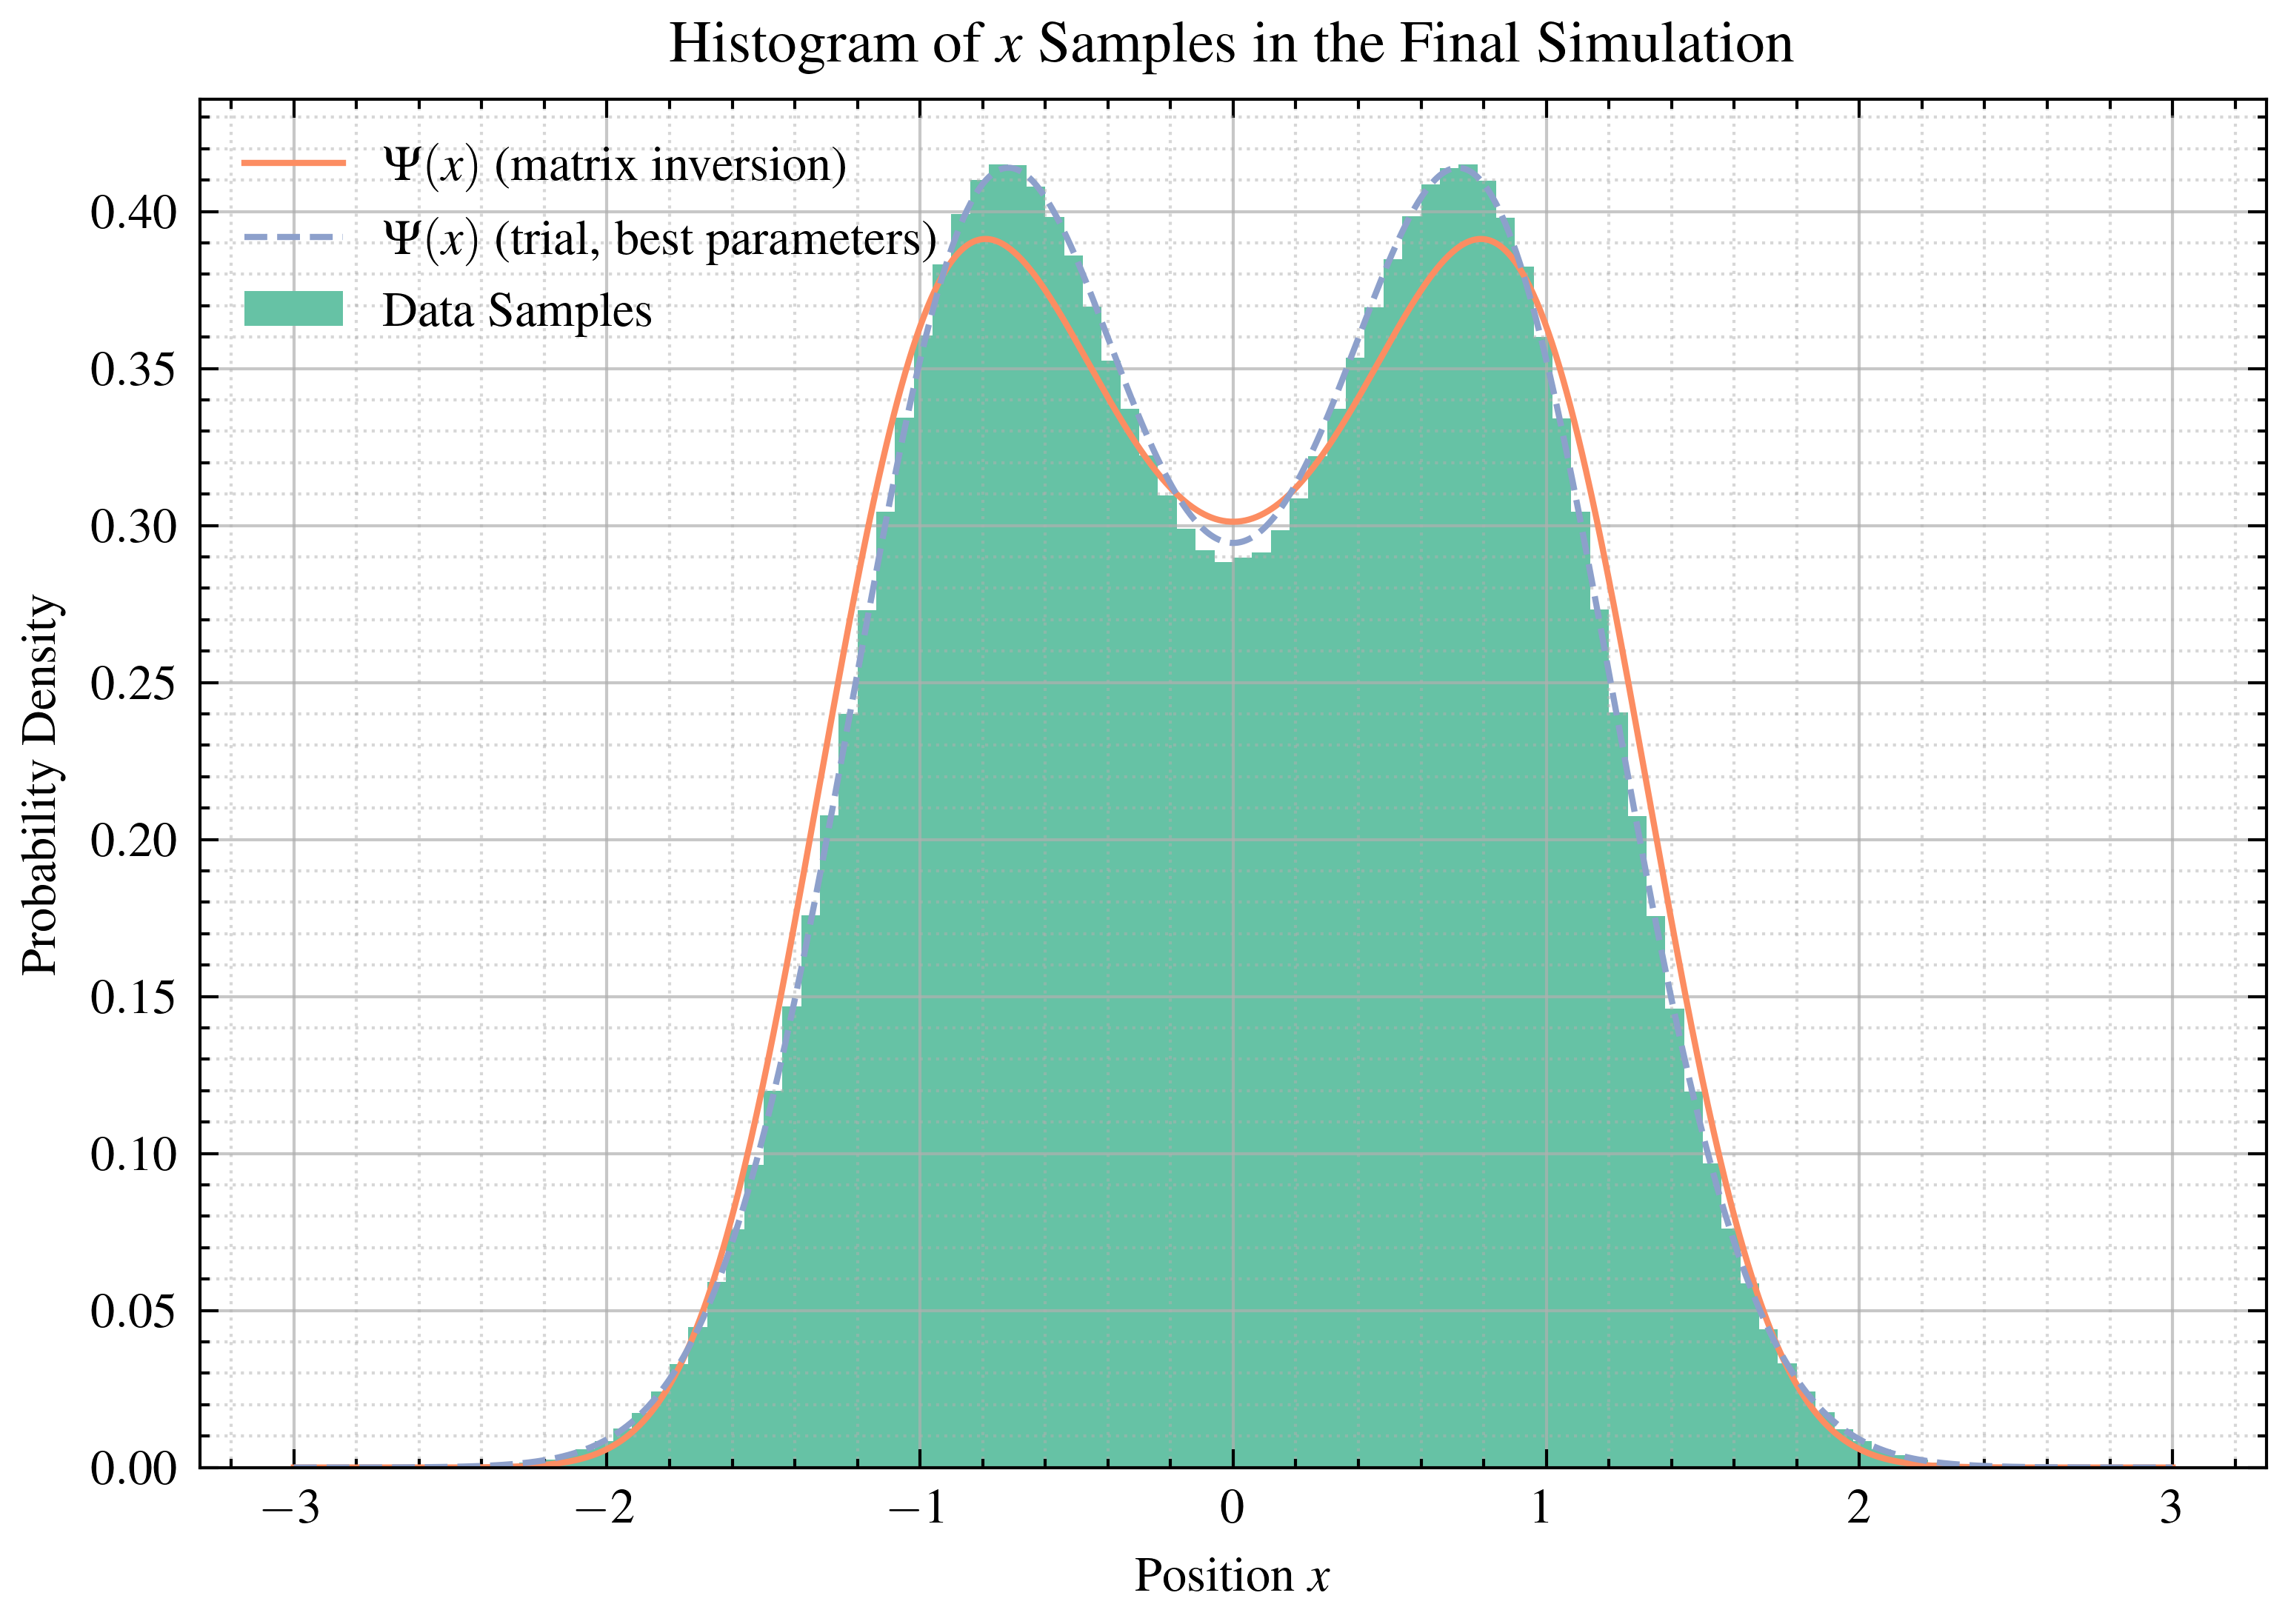

In [7]:
hist = np.loadtxt("../Exercises/Exercises_08/Exer_08_02/data/histogram.dat")
# ^^^ columns are: x_bin_left_edge, probability

bin_size = hist[1, 0] - hist[0, 0]

# Plot the histogram and the wavefunctions
fig = plt.figure(figsize=(6, 4))

plt.bar(hist[:, 0], hist[:, 1], width=bin_size, align="edge", label="Data Samples")
plt.plot(x, psi[0] ** 2, label=r"$\Psi(x)$ (matrix inversion)", c="C1")
plt.plot(
    x, psi_best**2, label=r"$\Psi(x)$ (trial, best parameters)", linestyle="--", c="C2"
)

plt.title("Histogram of $x$ Samples in the Final Simulation")
plt.xlabel("Position $x$")
plt.ylabel("Probability Density")

plt.legend(loc="upper left")
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle=":", alpha=0.5)

plt.show()

As we can see the data samples fits perfectly our trial wave function. But the trial wave function and the matrix inversion's wave function are different. 

We can see that the sum of two gaussian is a good approximation of the matrix inversion's wave function, but there is still a little difference from the two, that difference is probably caused by some factors we did not include in the guessed function.